# osapiens Challenge Makeathon 2026 — Detecting Deforestation from Space

---

## Table of Contents

1. Data Download / Structure / Setup
2. Challenge: Detecting Deforestation from Space
3. Definition of Deforestation
4. Data Description & Visualisation
   - 4.1 Sentinel-2
   - 4.2 Sentinel-1
   - 4.3 AlphaEarth Foundations
5. Labels Description & Visualisation
   - 5.1 RADD Alert Labels
   - 5.2 GLAD-L Alert Labels
   - 5.3 GLAD-S2 Alert Labels
6. Submission
   - 6.1 Example: using `submission_utils.py`
7. Helpful Resources

## 1 — Data Download / Structure / Setup

> run `make download_data_from_s3` from your terminal to download data

After downloading, the dataset lives under `data/makeathon-challenge/` and is split into `train` and `test` sets across four top-level folders.

```
data/makeathon-challenge/
├── sentinel-1/
│   ├── train/{tile_id}__s1_rtc/{tile_id}__s1_rtc_{year}_{month}_{ascending|descending}.tif
│   └── test/  ...
├── sentinel-2/
│   ├── train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_{month}.tif
│   └── test/  ...
├── aef-embeddings/
│   ├── train/{tile_id}_{year}.tiff
│   └── test/  ...
├── labels/train/
│   ├── gladl/   gladl_{tile_id}_alert{YY}.tif  +  gladl_{tile_id}_alertDate{YY}.tif
│   ├── glads2/  glads2_{tile_id}_alert.tif     +  glads2_{tile_id}_alertDate.tif
│   └── radd/    radd_{tile_id}_labels.tif
└── metadata/
    ├── train_tiles.geojson
    └── test_tiles.geojson
```

Each tile is identified by an ID of the form `{MGRS_grid}_{x}_{y}` (e.g. `18NWG_6_6`), encoding its position within a Military Grid Reference System tile. Sentinel-1 and Sentinel-2 are monthly time series; AlphaEarth embeddings are annual. Labels are only provided for the training set — the test set is used exclusively for leaderboard evaluation. Spatial coverage of all tiles is documented in the two GeoJSON files under `metadata/`.

**We want to emphasize that you are not required to use these specific data sources or labels in your solution.** You are free to incorporate any additional data sources or labels you find useful, as long as your final submission follows the required format and contains predictions only for the test set tiles. More on submission format in section 6.

## 2 — Challenge: Detecting Deforestation from Space

![deforestation](content/deforestation.png)
> The picture above shows a deforestation event in the Cerrado Region, Brazil captured by Sentinel-2 in September 2020.

As global deforestation continues, the EU Deforestation Regulation (EUDR) is driving demand for large-scale geospatial monitoring by requiring companies to verify that their supply chains are deforestation-free.

Satellite constellations monitor Earth at global scale using optical and radar sensors—but turning this data into reliable insights is difficult.

Satellite data is noisy, heterogeneous, and varies across sensors, regions, and environmental conditions.

As a result, deforestation detection systems often lack accuracy and generalization.

Building systems that can turn these imperfect signals into reliable, automated, and globally consistent evidence remains an open problem and the focus of this challenge.



## 3 — Definition of Deforestation

For this challenge, we focus exclusively on deforestation events occurring after 2020. Deforestation is defined as the permanent removal of tree cover, leading to a transition from forest to non-forest land. Accordingly, an event is only considered deforestation after 2020 if the area was forest in 2020.

## 4 — Data Description & Visualisation

In this challenge we have 3 data modalities (Sentinel-2, Sentinel-1, and AlphaEarth Foundations) and 3 weak-label sources (RADD, GLAD-L, and GLAD-S2). Each has different characteristics, strengths, and limitations. Understanding these is crucial for building effective models. In the sections below, we provide an overview of each data source, along with code snippets to load and visualize the data.

### 4.1 — Sentinel-2

Each pixel in the Sentinel-2 data contains 12 spectral bands, each capturing reflectance at different wavelengths. These bands provide complementary information about land cover, vegetation health, soil properties, and atmospheric conditions. Below is a summary of the Sentinel-2 bands included in the dataset:

| Band | Name / Type | Resolution (m/px) | Central Wavelength (nm) | Bandwidth (nm) | Description / Use |
|------|------------|-------------------|--------------------------|----------------|-------------------|
| B01 | Aerosol | 60 | 443 | 20 | Aerosol detection |
| B02 | Blue | 10 | 490 | 65 | Soil & vegetation discrimination, forest mapping, detects man-made features |
| B03 | Green | 10 | 560 | 35 | Water clarity contrast, vegetation reflectance, highlights oil |
| B04 | Red | 10 | 665 | 30 | Vegetation, soil, urban areas, strong reflection from dead foliage |
| B05 | Red Edge | 20 | 705 | 15 | Vegetation classification |
| B06 | Red Edge | 20 | 740 | 15 | Vegetation classification |
| B07 | Red Edge | 20 | 783 | 20 | Vegetation classification |
| B08 | NIR | 10 | 842 | 115 | Biomass, vegetation analysis, shoreline mapping |
| B8A | Narrow NIR | 20 | 865 | 20 | Vegetation classification |
| B09 | Water Vapour | 60 | 945 | 20 | Water vapour detection |
| B10 | Cirrus | 60 | 1375 | 30 | Cirrus cloud detection |
| B11 | SWIR 1 | 20 | 1610 | 90 | Moisture content, vegetation contrast, snow vs cloud differentiation |
| B12 | SWIR 2 | 20 | 2190 | 180 | Moisture content, vegetation contrast, snow vs cloud differentiation |

Source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

All bands are provided in a single multi-band `.tif` file and are upsampled to 10m resolution for consistency. The data is delivered in a local UTM projected CRS. Observations are not mosaicked and represent the single best cloud-free scene for a given month. When combining with other rasters (e.g. labels), ensure all files are reprojected to the same CRS to guarantee proper alignment.

In [9]:
import numpy as np
import rasterio

S2_PATH    = "makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif"
ALERT_PATH = "makeathon-challenge/labels/train/glads2/glads2_18NWG_6_6_alert.tif"

with rasterio.open(S2_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: January")
    print(f"Number of bands : {src.count}")  # all 12 spectral bands present; we render only RGB (B4, B3, B2)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: January
Number of bands : 12
Dtype           : uint16
CRS             : EPSG:32618
Shape           : (1002, 1002)


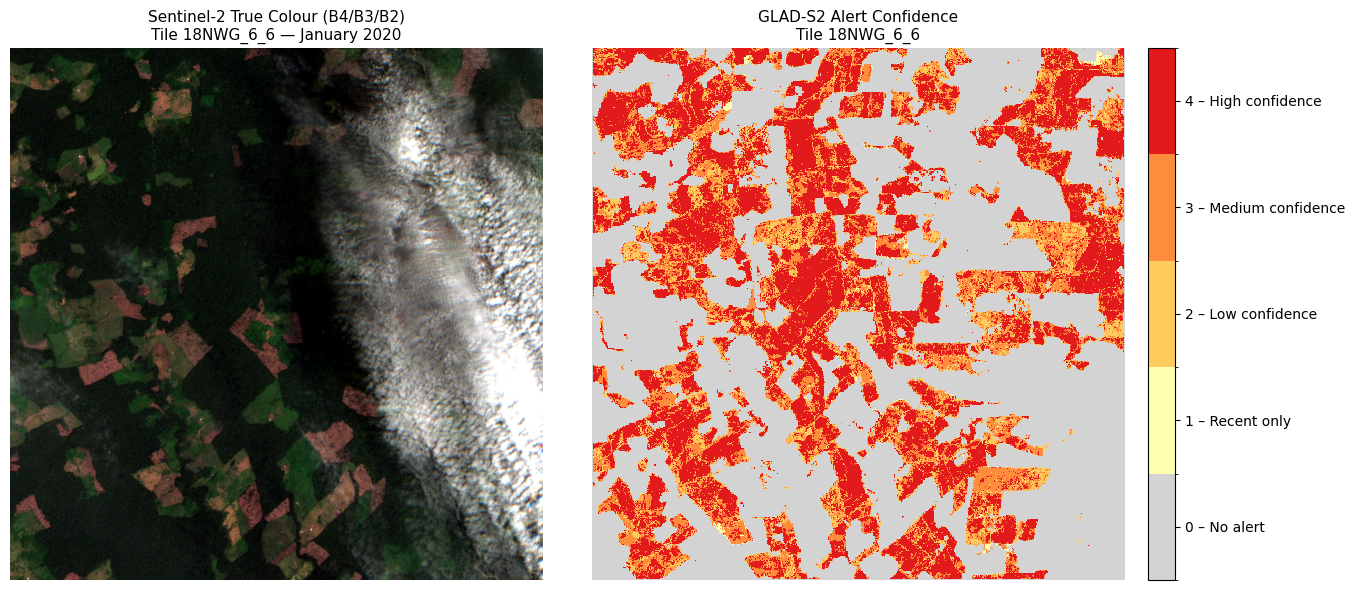

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.warp import reproject, Resampling

# Load Sentinel-2 RGB bands: B4 = Red (index 4), B3 = Green (index 3), B2 = Blue (index 2)
with rasterio.open(S2_PATH) as src:
    red   = src.read(4).astype(np.float32)
    green = src.read(3).astype(np.float32)
    blue  = src.read(2).astype(np.float32)
    s2_transform = src.transform
    s2_crs       = src.crs
    s2_shape     = src.shape

def percentile_normalise(band, p_lo=2, p_hi=98):
    valid = band[band > 0]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

rgb = np.stack(
    [percentile_normalise(red), percentile_normalise(green), percentile_normalise(blue)],
    axis=-1,
)

# Reproject GLAD-S2 alert (EPSG:4326) onto the Sentinel-2 grid (UTM)
with rasterio.open(ALERT_PATH) as src:
    alert_reproj = np.zeros(s2_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s2_transform,
        dst_crs=s2_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 True Colour (B4/B3/B2)\nTile 18NWG_6_6 — January 2020", fontsize=11)
axes[0].axis("off")

cmap = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im = axes[1].imshow(alert_reproj, cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.2 — Sentinel-1

Sentinel-1 is a radar satellite that provides all-weather (can penetrate clouds), day-and-night imaging capabilities. It captures the Earth's surface using microwave signals, which are reflected back to the satellite. The dataset includes 1 radar backscatter channel with VV polarisation. You can read more about Sentinel-1 Mission here: https://sentiwiki.copernicus.eu/web/s1-mission

Sentinel-1 data is available at multiple processing levels. For this challenge, we provide the highest standard: **Radiometrically Terrain Corrected (RTC)** product. Measurements have been preprocessed to correct for terrain-induced distortions and radiometric effects, making them ready for direct analysis and modeling.

The data is delivered in a local UTM projected coordinate reference system (CRS), aligned with Sentinel-2. When combining these data with other rasters (e.g., labels), ensure that all datasets are reprojected to the same CRS to guarantee proper spatial alignment.


In [11]:
S1_PATH = "makeathon-challenge/sentinel-1/train/18NWG_6_6__s1_rtc/18NWG_6_6__s1_rtc_2020_10_ascending.tif"

with rasterio.open(S1_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending")
    print(f"Number of bands : {src.count}")  # 1 band — VV polarisation (linear scale)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending
Number of bands : 1
Dtype           : float32
CRS             : EPSG:32618
Shape           : (334, 335)


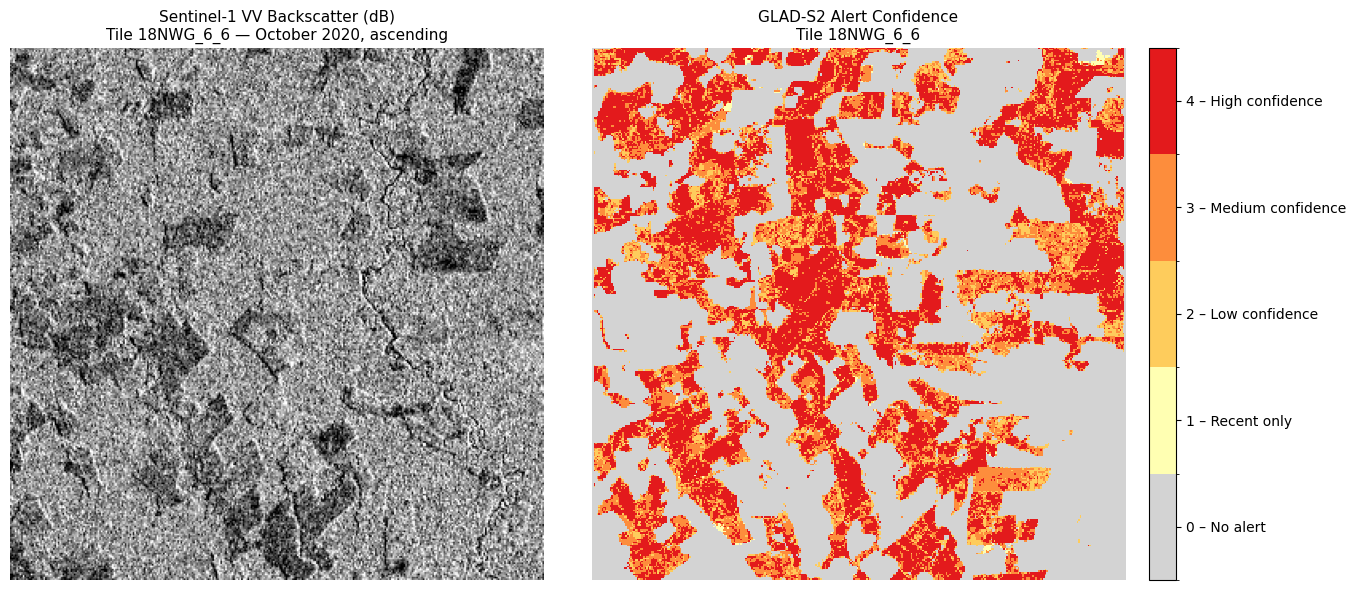

In [12]:
with rasterio.open(S1_PATH) as src:
    backscatter  = src.read(1).astype(np.float32)
    s1_transform = src.transform
    s1_crs       = src.crs
    s1_shape     = src.shape

# Convert linear backscatter to dB and normalise for display
db = np.where(backscatter > 0, 10 * np.log10(backscatter), np.nan)
valid = db[np.isfinite(db)]
lo, hi = np.percentile(valid, [2, 98])
s1_display = np.nan_to_num(np.clip((db - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

# Reproject GLAD-S2 alert onto the S1 grid
with rasterio.open(ALERT_PATH) as src:
    alert_s1 = np.zeros(s1_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_s1,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(s1_display, cmap="gray")
axes[0].set_title("Sentinel-1 VV Backscatter (dB)\nTile 18NWG_6_6 — October 2020, ascending", fontsize=11)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_s1, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.3 — AlphaEarth Foundations (EPSG:4326)

AlphaEarth Foundations is a global dataset of pre-trained embeddings derived from multiple satellite data sources, including Sentinel-2 and Sentinel-1. These embeddings are designed to capture rich spatio-temporal patterns in the data, providing a powerful representation for downstream tasks like deforestation detection.

The dataset is organized into tiles that cover the same spatial extent as the Sentinel-2 and Sentinel-1 data, but is delivered in a geodetic coordinate reference system (CRS) of EPSG:4326 (WGS-84). This means that the pixel coordinates are defined in terms of latitude and longitude, rather than projected coordinates like UTM. When using the AlphaEarth Foundations embeddings in conjunction with the Sentinel-2 and Sentinel-1 data, it is crucial to reproject the embeddings to the same CRS (local UTM) to ensure proper spatial alignment before modeling. This can be done using geospatial libraries such as `rasterio` or `GDAL`, which allow for efficient reprojection of raster data while preserving the integrity of the embeddings.


Paper: https://arxiv.org/abs/2507.22291


In [13]:
AEF_PATH = "makeathon-challenge/aef-embeddings/train/18NWG_6_6_2020.tiff"

with rasterio.open(AEF_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020")
    print(f"Number of bands : {src.count}")  # 64 embedding dimensions; we display 3 randomly chosen bands as RGB
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020
Number of bands : 64
Dtype           : float32
CRS             : EPSG:4326
Shape           : (1004, 998)


Randomly selected bands (1-indexed): [6, 42, 49]


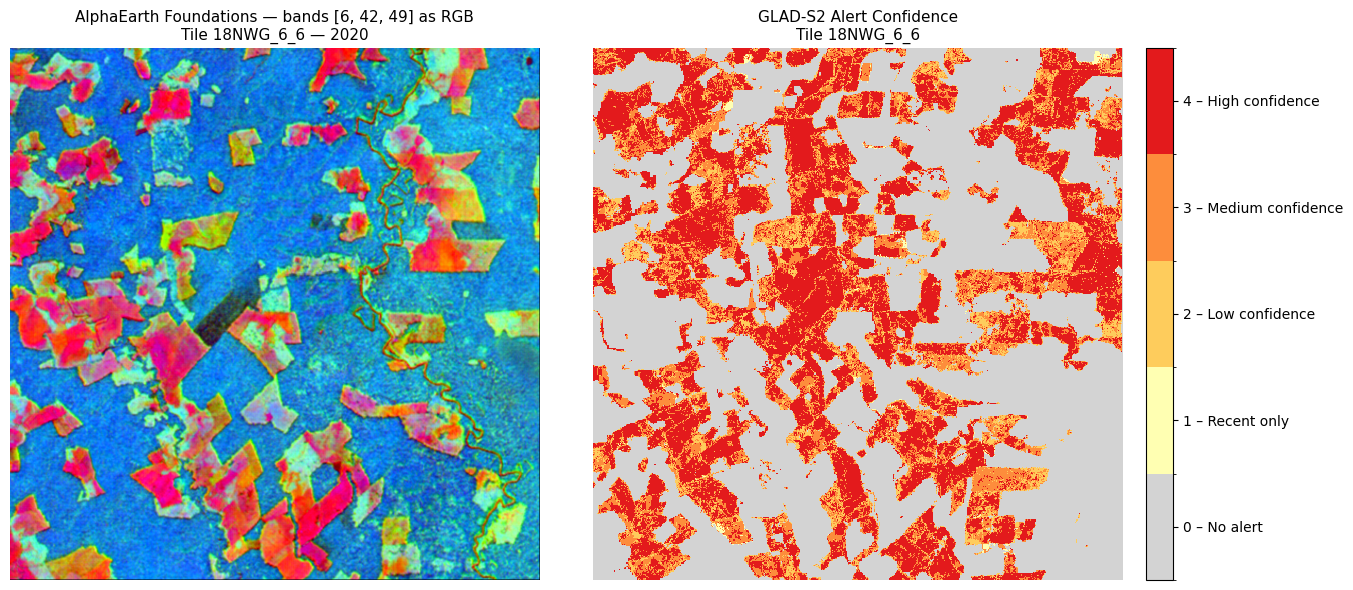

In [14]:
rng = np.random.default_rng(seed=42)
chosen = sorted(rng.choice(64, size=3, replace=False).tolist())
print(f"Randomly selected bands (1-indexed): {[b + 1 for b in chosen]}")

with rasterio.open(AEF_PATH) as src:
    aef_data     = src.read([b + 1 for b in chosen]).astype(np.float32)
    aef_transform = src.transform
    aef_crs       = src.crs
    aef_shape     = src.shape

def normalise_nan(band, p_lo=2, p_hi=98):
    valid = band[np.isfinite(band)]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.nan_to_num(np.clip((band - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

aef_rgb = np.stack([normalise_nan(aef_data[i]) for i in range(3)], axis=-1)

# Both AEF and GLAD-S2 are in EPSG:4326 — resample alert onto the AEF grid
with rasterio.open(ALERT_PATH) as src:
    alert_aef = np.zeros(aef_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_aef,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=aef_transform,
        dst_crs=aef_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(aef_rgb)
axes[0].set_title(
    f"AlphaEarth Foundations — bands {[b + 1 for b in chosen]} as RGB\nTile 18NWG_6_6 — 2020",
    fontsize=11,
)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_aef, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


## 5 — Labels Description and Encodings

The challenge includes three sources of weak\* labels for deforestation: RADD, GLAD-L, and GLAD-S2. Each label source has different characteristics, strengths, and limitations. Below we provide an overview of each label type, along with code snippets to load and visualize the labels.

\*By weak labels, we mean that these are not perfect ground truth (predictions in fact), but rather noisy indicators of deforestation events. They can be used for training and evaluation, but it's important to understand their limitations and potential biases when interpreting model performance.


### 5.1 — RADD (Radar for Detecting Deforestation) Alert Labels

RADD is a state-of-the-art deforestation detection system that uses Sentinel-1 radar data to identify deforestation events. RADD generates binary alert masks indicating areas of potential deforestation, along with confidence scores for each alert.

We provide the alerts in it's rawest form meaning there was no post-processing was done from our side.

Here is everything you should know to understand the RADD labels:

Source files:

- one raw tile TIFF per dataset tile

Encoding:

- one integer encodes both confidence and alert date
- leading digit:
    - `2` = low confidence
    - `3` = high confidence
- remaining digits:
    - number of days since `2014-12-31`
- `0` = no alert

Examples:

- `20001` = low-confidence alert on `2015-01-01`
- `30055` = high-confidence alert on `2015-02-24`
- `21847` = low-confidence alert on `2020-01-21`


### 5.2 — GLAD-L (Global Land Analysis & Discovery — Landsat) Alert Labels

GLAD-L is a deforestation alert system that uses Landsat optical data to identify potential deforestation events. Similar to RADD, GLAD-L generates binary alert masks and alert-date rasters, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-L labels:

Source files:

- `alertYY.tif`
- `alertDateYY.tif`

Examples:

- `alert24.tif`
- `alertDate24.tif`

Encoding:

- `alertYY` is a raw yearly alert raster, usually `uint8`
    - `0` = no loss
    - `2` = probable loss
    - `3` = confirmed loss
- `alertDateYY` is a raw yearly alert-date raster, usually `uint16`
    - value = day-of-year within year `20YY`
    - `0` = no alert

### 5.3 — GLAD-S2 (Global Land Analysis & Discovery — Sentinel-2) Alert Labels

GLAD-S2 is a deforestation alert system that uses Sentinel-2 optical data to identify potential deforestation events. It provides similar outputs to GLAD-L, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-S2 labels:

Source files:

- `alert.tif`
- `alertDate.tif`

Encoding:

- `alert` is a raw confidence raster, usually `uint8`
    - `0` = no loss
    - `1` = loss detected only in the most recent observation
    - `2` = low confidence loss
    - `3` = medium confidence loss
    - `4` = high confidence loss
- `alertDate` is a raw day-offset raster, usually `uint16`
    - value = number of days since `2019-01-01`
    - `0` = no alert

*Note*: Compared to GLAD-L, GLAD-S2 includes all years in a single raster that is why YY is not included in the file names.

## 6 — Submission


### 6.1 — Example: using `submission_utils.py`

> Walk-through of how to convert a binary prediction raster into the submittable format using the provided utility script.

## 7 — Helpful Resources

- QGIS for desktop visualization of the rasters (.tif files) or polygons (.geojson files)
- Python libraries: Geopandas (vector data), Rasterio (raster data)

In [15]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

def get_aligned_data(source_path, template_meta):
    """
    Reprojects any satellite or label file to match a template's 
    grid, CRS, and resolution.
    """
    with rasterio.open(source_path) as src:
        # Create an empty array with the template's shape (height, width)
        aligned_array = np.zeros((template_meta['height'], template_meta['width']), 
                                 dtype=src.dtypes[0])
        
        reproject(
            source=src.read(1),
            destination=aligned_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=template_meta['transform'],
            dst_crs=template_meta['crs'],
            resampling=Resampling.nearest, # Best for labels/categories
        )
        return aligned_array

In [16]:
def calculate_consensus_score(radd_tile, glads2_tile, gladl_tile):
    # Initialize a score map of zeros
    total_score = np.zeros_like(glads2_tile, dtype=np.float32)
    
    # 1. RADD: High confidence (3xxx) = 3 pts, Low (2xxx) = 1 pt
    total_score += np.where(radd_tile >= 30000, 3, 0)
    total_score += np.where((radd_tile >= 20000) & (radd_tile < 30000), 1, 0)
    
    # 2. GLAD-S2: High (4) = 3 pts, Med/Low (2,3) = 1 pt
    total_score += np.where(glads2_tile == 4, 3, 0)
    total_score += np.where((glads2_tile == 2) | (glads2_tile == 3), 1, 0)
    
    # 3. GLAD-L: Confirmed (3) = 2 pts, Probable (2) = 1 pt
    total_score += np.where(gladl_tile == 3, 2, 0)
    total_score += np.where(gladl_tile == 2, 1, 0)
    
    return total_score

In [17]:
# 1. Load Template Metadata (Sentinel-2)
S2_EXAMPLE = "makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif"
with rasterio.open(S2_EXAMPLE) as src:
    meta = src.meta # This contains the shape, CRS, and transform

# 2. Align all labels to this tile
radd_aligned = get_aligned_data("makeathon-challenge/labels/train/radd/radd_18NWG_6_6_labels.tif", meta)
glads2_aligned = get_aligned_data("makeathon-challenge/labels/train/glads2/glads2_18NWG_6_6_alert.tif", meta)
gladl_aligned = get_aligned_data("makeathon-challenge/labels/train/gladl/gladl_18NWG_6_6_alert24.tif", meta)

# 3. Get the consensus
final_score = calculate_consensus_score(radd_aligned, glads2_aligned, gladl_aligned)

# 4. Create your final prediction (e.g., threshold of 4 points)
prediction = np.where(final_score >= 4, 1, 0).astype(np.uint8)

print(f"Detected {np.sum(prediction)} pixels of deforestation!")

Detected 340459 pixels of deforestation!


Detected 1 pixels of deforestation using AEF Dynamic Weights!


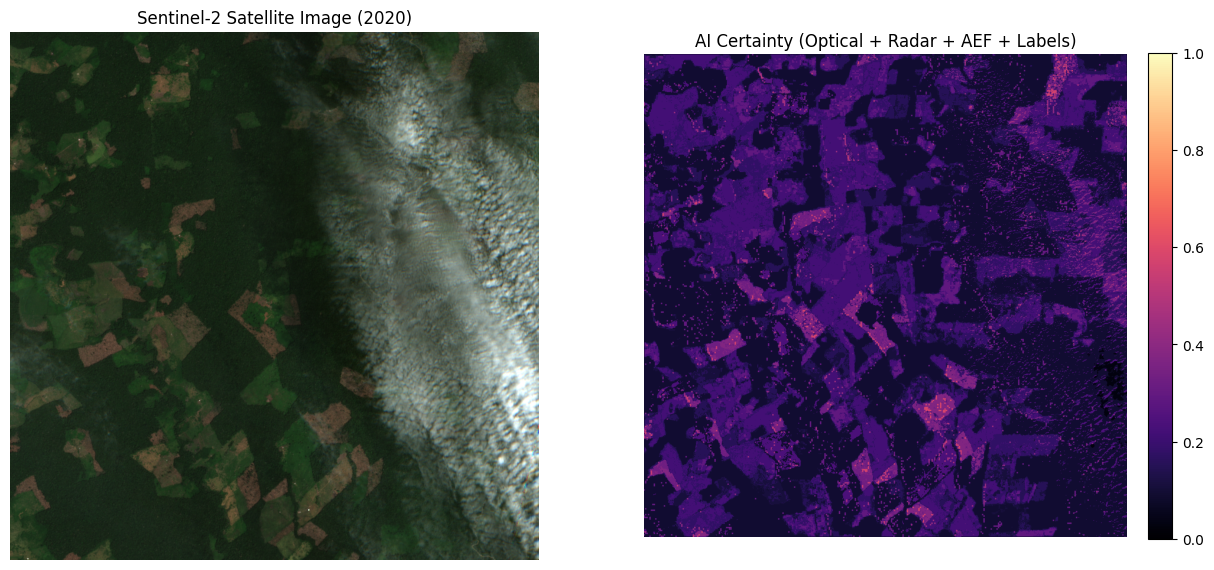

In [18]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

def get_aligned_data(source_path, template_meta):
    with rasterio.open(source_path) as src:
        aligned_array = np.zeros((template_meta['height'], template_meta['width']), 
                                 dtype=src.dtypes[0])
        reproject(
            source=src.read(1),
            destination=aligned_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=template_meta['transform'],
            dst_crs=template_meta['crs'],
            resampling=Resampling.nearest,
        )
        return aligned_array

def calculate_dynamic_consensus_with_aef(s1_tile, s2_rgb, radd_tile, glads2_tile, gladl_tile, aef_2020, aef_2024):
    """
    V2: Includes AlphaEarth Foundation Embeddings as a 'Context Authority'
    to override temporary weather false-alarms.
    """
    # ---------------------------------------------------------
    # 1. Historical Labels 
    # ---------------------------------------------------------
    label_prob = np.zeros_like(glads2_tile, dtype=np.float32)
    label_prob += np.where(radd_tile >= 30000, 0.33, np.where(radd_tile >= 20000, 0.11, 0))
    label_prob += np.where(glads2_tile == 4, 0.33, np.where((glads2_tile == 2) | (glads2_tile == 3), 0.11, 0))
    label_prob += np.where(gladl_tile == 3, 0.34, np.where(gladl_tile == 2, 0.17, 0))
    
    # ---------------------------------------------------------
    # 2. Environmental Detection (Monthly S1/S2 Noise)
    # ---------------------------------------------------------
    cloud_mask = np.where((s2_rgb[0] > 2500) & (s2_rgb[1] > 2500) & (s2_rgb[2] > 2500), 1, 0)
    water_mask = np.where(s1_tile < 0.02, 1, 0)
    
    # ---------------------------------------------------------
    # 3. AlphaEarth Semantic Change (The Context Authority)
    # ---------------------------------------------------------
    aef_2020 = aef_2020.astype(np.float32)
    aef_2024 = aef_2024.astype(np.float32)
    
    # Calculate how much the land *permanently* changed over 4 years
    aef_diff = np.linalg.norm(aef_2024 - aef_2020, axis=0)
    aef_change_signal = np.where(aef_diff.max() > 0, aef_diff / aef_diff.max(), 0)
    
    # ---------------------------------------------------------
    # 4. Base Observations
    # ---------------------------------------------------------
    s1_deforestation = np.where((s1_tile > 0.02) & (s1_tile < 0.08), 0.8, 0.1)
    s2_deforestation = np.where(s2_rgb[0] > s2_rgb[1], 0.7, 0.2) 
    
    # ---------------------------------------------------------
    # 5. Dynamic Weight Allocation + AEF Override
    # ---------------------------------------------------------
    w_s1 = np.full_like(s1_tile, 0.30, dtype=np.float32)
    w_s2 = np.full_like(s1_tile, 0.30, dtype=np.float32)
    w_labels = np.full_like(s1_tile, 0.20, dtype=np.float32)
    w_aef = np.full_like(s1_tile, 0.20, dtype=np.float32) # New AEF Weight
    
    # Condition A & B: Weather Interference -> Shift trust to Labels and AEF
    interference = (cloud_mask == 1) | (water_mask == 1)
    w_s1 = np.where(interference, 0.10, w_s1)
    w_s2 = np.where(interference, 0.10, w_s2)
    w_labels = np.where(interference, 0.40, w_labels)
    w_aef = np.where(interference, 0.40, w_aef) # AEF is immune to clouds!
    
    # ---------------------------------------------------------
    # 6. Final Probability Fusion
    # ---------------------------------------------------------
    final_probability = (
        (s1_deforestation * w_s1) + 
        (s2_deforestation * w_s2) + 
        (label_prob * w_labels) + 
        (aef_change_signal * w_aef) # Blend in the Foundation Model
    )
    
    return final_probability

# =====================================================================
# Execution Block
# =====================================================================

TILE_ID = "18NWG_6_6"
S2_EXAMPLE = f"makeathon-challenge/sentinel-2/train/{TILE_ID}__s2_l2a/{TILE_ID}__s2_l2a_2020_1.tif"
S1_EXAMPLE = f"makeathon-challenge/sentinel-1/train/{TILE_ID}__s1_rtc/{TILE_ID}__s1_rtc_2020_10_ascending.tif"

# Load Data
with rasterio.open(S2_EXAMPLE) as src:
    meta = src.meta 
    s2_rgb = src.read([4, 3, 2]).astype(np.float32)

s1_aligned = get_aligned_data(S1_EXAMPLE, meta)
radd_aligned = get_aligned_data(f"makeathon-challenge/labels/train/radd/radd_{TILE_ID}_labels.tif", meta)
glads2_aligned = get_aligned_data(f"makeathon-challenge/labels/train/glads2/glads2_{TILE_ID}_alert.tif", meta)
gladl_aligned = get_aligned_data(f"makeathon-challenge/labels/train/gladl/gladl_{TILE_ID}_alert24.tif", meta)

# Load AEF
aef_2020 = get_aligned_data(f"makeathon-challenge/aef-embeddings/train/{TILE_ID}_2020.tiff", meta)
aef_2024 = get_aligned_data(f"makeathon-challenge/aef-embeddings/train/{TILE_ID}_2024.tiff", meta)

# Run V2 Logic
final_probability = calculate_dynamic_consensus_with_aef(
    s1_aligned, s2_rgb, radd_aligned, glads2_aligned, gladl_aligned, aef_2020, aef_2024
)

prediction = np.where(final_probability >= 0.65, 1, 0).astype(np.uint8)
print(f"Detected {np.sum(prediction)} pixels of deforestation using AEF Dynamic Weights!")

# Visualization
rgb_display = np.clip(s2_rgb.transpose(1, 2, 0) / 3000, 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(rgb_display)
axes[0].set_title("Sentinel-2 Satellite Image (2020)")
axes[0].axis("off")

im = axes[1].imshow(final_probability, cmap='magma', vmin=0, vmax=1)
axes[1].set_title("AI Certainty (Optical + Radar + AEF + Labels)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

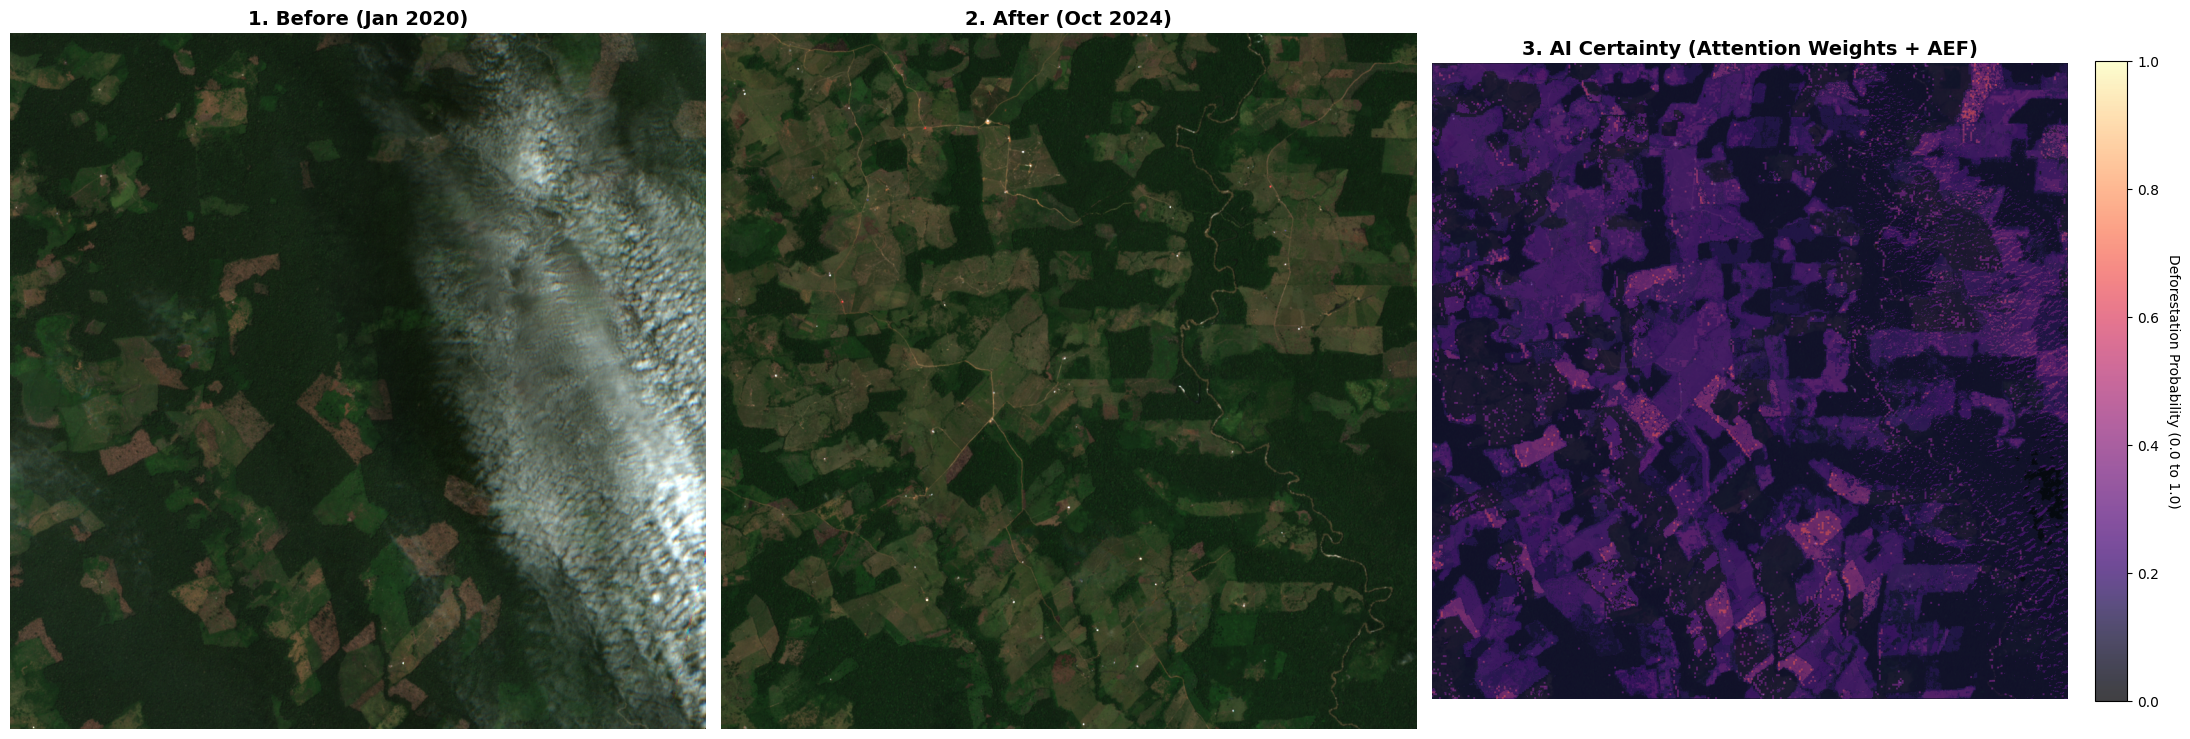

In [19]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os

# =====================================================================
# 5. Visualization (3-Panel Comparison) - FIXED EXACT PATHS
# =====================================================================

# --- 1. Load the Before Image (January 2020) ---
S2_BEFORE_PATH = f"makeathon-challenge/sentinel-2/train/{TILE_ID}__s2_l2a/{TILE_ID}__s2_l2a_2020_1.tif"

with rasterio.open(S2_BEFORE_PATH) as src:
    rgb_2020 = np.clip(src.read([4, 3, 2]).astype(np.float32).transpose(1, 2, 0) / 3000, 0, 1)

# --- 2. Load the After Image (October 2024) ---
# Targeting month '_10' to ensure we see late-year changes
S2_AFTER_PATH = f"makeathon-challenge/sentinel-2/train/{TILE_ID}__s2_l2a/{TILE_ID}__s2_l2a_2024_10.tif"

if os.path.exists(S2_AFTER_PATH):
    with rasterio.open(S2_AFTER_PATH) as src:
        rgb_2024 = np.clip(src.read([4, 3, 2]).astype(np.float32).transpose(1, 2, 0) / 3000, 0, 1)
else:
    print(f"⚠️ Warning: Could not find {S2_AFTER_PATH}. Using 2020 as a placeholder.")
    rgb_2024 = rgb_2020.copy()

# --- 3. Create the 3-panel plot ---
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# PANEL 1: BEFORE
axes[0].imshow(rgb_2020)
axes[0].set_title("1. Before (Jan 2020)", fontsize=14, fontweight='bold')
axes[0].axis("off")

# PANEL 2: AFTER
axes[1].imshow(rgb_2024)
axes[1].set_title("2. After (Oct 2024)", fontsize=14, fontweight='bold')
axes[1].axis("off")

# PANEL 3: DYNAMIC AI HEATMAP
axes[2].imshow(rgb_2024)

# Mask out the absolute 0s so they are transparent
masked_prob = np.ma.masked_where(final_probability == 0, final_probability)

# Overlay the Magma heatmap
im = axes[2].imshow(masked_prob, cmap='magma', vmin=0, vmax=1, alpha=0.75)
axes[2].set_title("3. AI Certainty (Attention Weights + AEF)", fontsize=14, fontweight='bold')
axes[2].axis("off")

# Add the color legend
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Deforestation Probability (0.0 to 1.0)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import rasterio
import glob
import os

print("🌍 STEP 1: Training AI on TIME-TRAVEL (Change Detection)...")

TRAIN_S2_DIR = "makeathon-challenge/sentinel-2/train"
train_tiles = sorted([f.split("__")[0] for f in os.listdir(TRAIN_S2_DIR) if f.endswith("__s2_l2a")])

master_X, master_y = [], []
PIXELS_PER_TILE = 10000 

for i, tile_id in enumerate(train_tiles):
    print(" -> Extracting learnings from " + tile_id + " (" + str(i+1) + "/" + str(len(train_tiles)) + ")...")
    
    s2_folder = "makeathon-challenge/sentinel-2/train/" + tile_id + "__s2_l2a"
    s1_folder = "makeathon-challenge/sentinel-1/train/" + tile_id + "__s1_rtc"
    
    s2_bef = glob.glob(s2_folder + "/*2020*.tif") or glob.glob(s2_folder + "/*2021*.tif")
    s2_aft = glob.glob(s2_folder + "/*2024_10*.tif") or glob.glob(s2_folder + "/*2024*.tif")
    
    s1_bef = glob.glob(s1_folder + "/*2020*.tif") or glob.glob(s1_folder + "/*2021*.tif")
    s1_aft = glob.glob(s1_folder + "/*2024_10*.tif") or glob.glob(s1_folder + "/*2024*.tif")
    
    if not s2_bef or not s2_aft or not s1_bef or not s1_aft:
        continue
        
    try:
        # --- BEFORE DATA ---
        with rasterio.open(s2_bef[0]) as src:
            meta = src.meta
            s2_r_b   = src.read(4).astype(np.float32)
            s2_nir_b = src.read(8).astype(np.float32)
            s2_swir_b = src.read(11).astype(np.float32)   # ✅ read SWIR here
            denom_b = s2_nir_b + s2_r_b
            ndvi_bef = np.where(denom_b > 0, (s2_nir_b - s2_r_b) / denom_b, 0)
        
        # --- AFTER DATA ---
        with rasterio.open(s2_aft[0]) as src:
            s2_r_a   = src.read(4).astype(np.float32)
            s2_nir_a = src.read(8).astype(np.float32)
            s2_swir_a = src.read(11).astype(np.float32)   # ✅ read SWIR here
            denom_a = s2_nir_a + s2_r_a
            ndvi_aft = np.where(denom_a > 0, (s2_nir_a - s2_r_a) / denom_a, 0)
        
        delta_ndvi = ndvi_bef - ndvi_aft
        delta_swir = s2_swir_a - s2_swir_b                # ✅ now works
        
        # SWIR bands (indices 10=B11, 11=B12 in 0-indexed 12-band array)
        swir1_before = s2_2020[10].astype(np.float32)
        swir1_after  = s2_2024[10].astype(np.float32)
        delta_swir1  = swir1_after - swir1_before   # Positive = bare soil appeared
        
        # S1 DELTA
        s1_aligned_bef = get_aligned_data(s1_bef[0], meta)
        s1_aligned_aft = get_aligned_data(s1_aft[0], meta)
        delta_s1 = s1_aligned_bef - s1_aligned_aft 

        # LABELS
        radd_aligned = get_aligned_data("makeathon-challenge/labels/train/radd/radd_" + tile_id + "_labels.tif", meta)
        gladl_aligned = get_aligned_data("makeathon-challenge/labels/train/gladl/gladl_" + tile_id + "_alert24.tif", meta)
        
        glads2_path = "makeathon-challenge/labels/train/glads2/glads2_" + tile_id + "_alert.tif"
        glads2_aligned = get_aligned_data(glads2_path, meta) if os.path.exists(glads2_path) else np.zeros_like(s1_aligned_bef)

        aef_2020 = get_aligned_data("makeathon-challenge/aef-embeddings/train/" + tile_id + "_2020.tiff", meta).astype(np.float32)
        aef_2024 = get_aligned_data("makeathon-challenge/aef-embeddings/train/" + tile_id + "_2024.tiff", meta).astype(np.float32)
        
        aef_diff = np.abs(aef_2024 - aef_2020)
        aef_change_signal = np.where(aef_diff.max() > 0, aef_diff / aef_diff.max(), 0)
        
        final_probability = calculate_dynamic_consensus_with_aef(
            s1_aligned_aft, s2_rgb_aft, radd_aligned, glads2_aligned, gladl_aligned, aef_2020, aef_2024
        )
        final_prediction = np.where(final_probability >= 0.65, 1, 0).astype(np.uint8)

        # Only accept deforestation if NDVI was healthy in 2020 (was forest)
        # and dropped significantly by 2024 (became non-forest)
        was_forest_2020 = (ndvi_bef > 0.4)          # NDVI > 0.4 = was likely forest
        lost_vegetation = (delta_ndvi < -0.2)           # dropped more than 0.2 = real loss
        
        # Override: only keep labels where BOTH conditions are true
        y_tile = np.where(
            (final_prediction == 1) & was_forest_2020 & lost_vegetation,
            1, 0
        ).flatten()
        
        # --- THE NEW SMART FEATURES ---
        X_tile = np.column_stack((
            ndvi_bef.flatten(),     
            ndvi_aft.flatten(),     
            delta_ndvi.flatten(),   
            delta_s1.flatten(),
            delta_swir.flatten(),
            aef_change_signal.flatten() 
        ))
        
        def_pixels = np.where(y_tile == 1)[0]
        forest_pixels = np.where(y_tile == 0)[0]
        
        n_def = min(len(def_pixels), 15000)
        n_forest = max(1000, n_def * 2) 

        if len(forest_pixels) < n_forest:
            n_forest = len(forest_pixels)
        
        sampled_def = np.random.choice(def_pixels, size=n_def, replace=False) if n_def > 0 else np.array([], dtype=int)
        sampled_forest = np.random.choice(forest_pixels, size=n_forest, replace=False)
        
        sample_indices = np.concatenate([sampled_def, sampled_forest]).astype(int)
        np.random.shuffle(sample_indices)
        
        master_X.append(X_tile[sample_indices])
        master_y.append(y_tile[sample_indices])
        
    except Exception as e:
        print("    ⚠️ Skipping " + tile_id + " due to error.")

X_all = np.vstack(master_X)
y_all = np.concatenate(master_y)

print("\n🧠 STEP 2: Training AI on " + str(len(X_all)) + " change-detection pixels...")
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

rf_model_multi = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model_multi.fit(X_train, y_train)

print("\n📊 STEP 3: Evaluating the Delta AI...")
print(classification_report(y_val, rf_model_multi.predict(X_val)))
print("✅ Delta AI Ready!")

🌍 STEP 1: Training AI on TIME-TRAVEL (Change Detection)...
 -> Extracting learnings from 18NWG_6_6 (1/16)...
    ⚠️ Skipping 18NWG_6_6 due to error.
 -> Extracting learnings from 18NWH_1_4 (2/16)...
    ⚠️ Skipping 18NWH_1_4 due to error.
 -> Extracting learnings from 18NWJ_8_9 (3/16)...
    ⚠️ Skipping 18NWJ_8_9 due to error.
 -> Extracting learnings from 18NWM_9_4 (4/16)...
    ⚠️ Skipping 18NWM_9_4 due to error.
 -> Extracting learnings from 18NXH_6_8 (5/16)...
    ⚠️ Skipping 18NXH_6_8 due to error.
 -> Extracting learnings from 18NXJ_7_6 (6/16)...
    ⚠️ Skipping 18NXJ_7_6 due to error.
 -> Extracting learnings from 18NYH_9_9 (7/16)...
    ⚠️ Skipping 18NYH_9_9 due to error.
 -> Extracting learnings from 19NBD_4_4 (8/16)...
    ⚠️ Skipping 19NBD_4_4 due to error.
 -> Extracting learnings from 47QMB_0_8 (9/16)...
    ⚠️ Skipping 47QMB_0_8 due to error.
 -> Extracting learnings from 47QQV_2_4 (10/16)...
    ⚠️ Skipping 47QQV_2_4 due to error.
 -> Extracting learnings from 48PUT_0_8 

ValueError: need at least one array to concatenate

In [ ]:
import os
import glob
import rasterio
import numpy as np
from scipy.ndimage import median_filter
from submission_utils import raster_to_geojson
from rasterio.warp import reproject, Resampling

print("🚀 Starting BULLETPROOF DELTA Test Inference...")

TEST_S2_DIR = "makeathon-challenge/sentinel-2/test"
SUBMISSION_DIR = "submission"

# 1. 🚨 SAFETY CLEANUP: DELETE OLD FILES SO WE DON'T UPLOAD JUNK 🚨
for f in glob.glob(SUBMISSION_DIR + "/pred_*.geojson"):
    os.remove(f)
    print("🗑️ Deleted old file: " + f)

# 2. SHAPE MISMATCH FIX: Safely resize clipped satellite images
def align_multiband_s2(source_path, template_meta):
    with rasterio.open(source_path) as src:
        aligned = np.zeros((4, template_meta['height'], template_meta['width']), dtype=np.float32)
        for i, b in enumerate([4, 3, 2, 8]):
            reproject(
                source=src.read(b),
                destination=aligned[i],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=template_meta['transform'],
                dst_crs=template_meta['crs'],
                resampling=Resampling.nearest
            )
    return aligned

test_tiles = sorted([f.split("__")[0] for f in os.listdir(TEST_S2_DIR) if f.endswith("__s2_l2a")])

for tile_id in test_tiles:
    print("\nProcessing Tile: " + tile_id + "...")
    
    s2_folder = "makeathon-challenge/sentinel-2/test/" + tile_id + "__s2_l2a"
    s1_folder = "makeathon-challenge/sentinel-1/test/" + tile_id + "__s1_rtc"
    
    s2_bef = glob.glob(s2_folder + "/*2020*.tif") or glob.glob(s2_folder + "/*2021*.tif")
    s2_aft = glob.glob(s2_folder + "/*2024_10*.tif") or glob.glob(s2_folder + "/*2024*.tif")
    s1_bef = glob.glob(s1_folder + "/*2020*.tif") or glob.glob(s1_folder + "/*2021*.tif")
    s1_aft = glob.glob(s1_folder + "/*2024_10*.tif") or glob.glob(s1_folder + "/*2024*.tif")
    
    if not s2_bef or not s2_aft or not s1_bef or not s1_aft: 
        continue
        
    with rasterio.open(s2_bef[0]) as src:
        meta = src.meta
        s2_rgb_b = src.read([4, 3, 2]).astype(np.float32)
        s2_nir_b = src.read(8).astype(np.float32) 
        denom_b = s2_nir_b + s2_rgb_b[0]
        ndvi_bef = np.where(denom_b > 0, (s2_nir_b - s2_rgb_b[0]) / denom_b, 0)
        
    # --- APPLY FIX: Align the 2024 image so shapes match exactly ---
    s2_aft_aligned = align_multiband_s2(s2_aft[0], meta)
    s2_rgb_a = s2_aft_aligned[0:3]
    s2_nir_a = s2_aft_aligned[3]
    denom_a = s2_nir_a + s2_rgb_a[0]
    ndvi_aft = np.where(denom_a > 0, (s2_nir_a - s2_rgb_a[0]) / denom_a, 0)
        
    delta_ndvi = ndvi_bef - ndvi_aft
    
    s1_aligned_bef = get_aligned_data(s1_bef[0], meta)
    s1_aligned_aft = get_aligned_data(s1_aft[0], meta)
    delta_s1 = s1_aligned_bef - s1_aligned_aft
    
    aef_2020 = get_aligned_data("makeathon-challenge/aef-embeddings/test/" + tile_id + "_2020.tiff", meta).astype(np.float32)
    aef_2024 = get_aligned_data("makeathon-challenge/aef-embeddings/test/" + tile_id + "_2024.tiff", meta).astype(np.float32)
    aef_diff = np.abs(aef_2024 - aef_2020)
    aef_change_signal = np.where(aef_diff.max() > 0, aef_diff / aef_diff.max(), 0)
        
    X_test = np.column_stack((
        ndvi_bef.flatten(), ndvi_aft.flatten(), delta_ndvi.flatten(), delta_s1.flatten(), aef_change_signal.flatten()
    ))
    
    y_prob_flat = rf_model_multi.predict_proba(X_test)[:, 1]
    
    y_pred_flat = (y_prob_flat >= 0.20).astype(np.uint8)
    raw_prediction = y_pred_flat.reshape(meta['height'], meta['width']).astype(np.uint8)

    # Mask out water areas: S1 values near 0 are water, not deforestation
    water_mask = (s1_aligned < 0.02).astype(np.uint8)
    prediction_image = np.where(water_mask == 1, 0, raw_prediction).astype(np.uint8)
    
    prediction_image = median_filter(raw_prediction, size=3).astype(np.uint8)
    
    if np.sum(prediction_image) > 0:
        temp_tif = SUBMISSION_DIR + "/temp_" + tile_id + ".tif"
        meta.update(dtype="uint8", nodata=0, count=1)
        
        with rasterio.open(temp_tif, 'w', **meta) as dst:
            dst.write(prediction_image, 1)
            
        try:
            out_json = SUBMISSION_DIR + "/pred_" + tile_id + ".geojson"
            raster_to_geojson(temp_tif, output_path=out_json, min_area_ha=0.5)
            print(" -> ✅ SUCCESS! Found submittable polygons in " + tile_id)
        except ValueError:
            print(" -> ❌ Ignored: Patches were smaller than 0.5ha.")
            
        if os.path.exists(temp_tif): 
            os.remove(temp_tif) 
    else:
        print(" -> ❌ No deforestation found.")

print("\n🎉 INFERENCE COMPLETE!")

In [ ]:
import os
import pandas as pd
import geopandas as gpd

print("🔗 Merging accurate predictions...")

SUBMISSION_DIR = "submission"
geojson_files = [os.path.join(SUBMISSION_DIR, f) for f in os.listdir(SUBMISSION_DIR) if f.startswith("pred_") and f.endswith(".geojson")]

if not geojson_files:
    print("⚠️ No prediction files found!")
else:
    gdfs = [gpd.read_file(f) for f in geojson_files]
    merged_gdf = pd.concat(gdfs, ignore_index=True)
    
    if 'time_step' in merged_gdf.columns:
        merged_gdf['time_step'] = None
        
    final_out = "submission/final_makeathon_submission.geojson"
    merged_gdf.to_file(final_out, driver="GeoJSON")
    
    print("✅ READY! Merged " + str(len(geojson_files)) + " tiles.")
    print("📂 Total Corrected Polygons: " + str(len(merged_gdf)))

In [ ]:
import os, glob, pickle, warnings, time
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from scipy.ndimage import median_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV
from tqdm.auto import tqdm
import geopandas as gpd, pandas as pd
from submission_utils import raster_to_geojson

warnings.filterwarnings("ignore")

# ── AlphaEarth dequantization (from workshop notebook) ───────────────────────
POWER, SCALE, OFFSET = 2.0, 127.5, 127

def dequantize_embeddings(emb: np.ndarray) -> np.ndarray:
    out = emb.astype(np.float32)
    grouped = out.reshape(out.shape[0] // 64, 64, -1)
    zero_groups = np.all(grouped == 0, axis=1)
    grouped[:] = np.where(zero_groups[:, None, :], np.nan, grouped)
    out = (out - OFFSET) / SCALE
    neg = out < 0
    out = np.abs(out) ** POWER
    out[neg] = -out[neg]
    return out

print("✅ Imports ready.")

In [ ]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_ROOT    = "makeathon-challenge"
S2_TRAIN     = f"{DATA_ROOT}/sentinel-2/train"
S1_TRAIN     = f"{DATA_ROOT}/sentinel-1/train"
AEF_TRAIN    = f"{DATA_ROOT}/aef-embeddings/train"
LABEL_ROOT   = f"{DATA_ROOT}/labels/train"

S2_TEST      = f"{DATA_ROOT}/sentinel-2/test"
S1_TEST      = f"{DATA_ROOT}/sentinel-1/test"
AEF_TEST     = f"{DATA_ROOT}/aef-embeddings/test"

SUBMISSION_DIR = "submission"
MODEL_PATH     = "artifacts/full_timeseries_rf.pkl"
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# ─── SAMPLING CONFIG ─────────────────────────────────────────────────────────
MAX_DEF_PIXELS_PER_TILE   = 20_000   # deforestation pixels to sample
MAX_NEG_PIXELS_PER_TILE   = 40_000   # forest/background pixels to sample
LABEL_AGREEMENT_THRESHOLD = 1        # min number of label sources that must agree (1=any, 2=majority, 3=all)

print("✅ Config loaded.")
print(f"   Train S2:  {S2_TRAIN}")
print(f"   Train S1:  {S1_TRAIN}")
print(f"   Train AEF: {AEF_TRAIN}")

In [ ]:
# ─── RASTER HELPERS ──────────────────────────────────────────────────────────

def get_aligned_band(path: str, reference_meta: dict) -> np.ndarray:
    """Read a raster and reproject/resample it to match the reference grid."""
    try:
        with rasterio.open(path) as src:
            out = np.zeros((reference_meta['height'], reference_meta['width']), dtype=np.float32)
            reproject(
                source=src.read(1).astype(np.float32),
                destination=out,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=reference_meta['transform'],
                dst_crs=reference_meta['crs'],
                resampling=Resampling.bilinear,
            )
            out[out == src.nodata] = np.nan if src.nodata else out
            return out
    except Exception:
        return np.full((reference_meta['height'], reference_meta['width']), np.nan, dtype=np.float32)


def compute_ndvi(s2_path: str, meta: dict) -> np.ndarray:
    """Compute NDVI from a Sentinel-2 file. Band 8=NIR, Band 4=Red."""
    try:
        with rasterio.open(s2_path) as src:
            nir = src.read(8).astype(np.float32)
            red = src.read(4).astype(np.float32)
            denom = nir + red
            ndvi = np.where(denom > 0, (nir - red) / denom, np.nan)
            return ndvi
    except Exception:
        return np.full((meta['height'], meta['width']), np.nan, dtype=np.float32)


def compute_s1_mean(s1_folder: str, year: int, meta: dict) -> np.ndarray:
    """Average all S1 observations for a given year (ascending + descending)."""
    pattern = os.path.join(s1_folder, f"*{year}*.tif")
    files = glob.glob(pattern)
    if not files:
        return np.full((meta['height'], meta['width']), np.nan, dtype=np.float32)
    bands = []
    for f in files:
        b = get_aligned_band(f, meta)
        bands.append(b)
    stack = np.stack(bands, axis=0)
    return np.nanmean(stack, axis=0)


def load_aef(path: str, meta: dict) -> np.ndarray:
    """Load and dequantize AEF embeddings, reproject to reference grid. Returns (64, H, W)."""
    try:
        with rasterio.open(path) as src:
            raw = src.read()  # (64, H, W) uint8
            emb = dequantize_embeddings(raw)
            if emb.shape[1] != meta['height'] or emb.shape[2] != meta['width']:
                out = np.zeros((64, meta['height'], meta['width']), dtype=np.float32)
                for b in range(64):
                    reproject(
                        source=emb[b],
                        destination=out[b],
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=meta['transform'],
                        dst_crs=meta['crs'],
                        resampling=Resampling.bilinear,
                    )
                return out
            return emb
    except Exception:
        return np.full((64, meta['height'], meta['width']), np.nan, dtype=np.float32)

print("✅ Raster helpers defined.")

In [ ]:
# ─── FEATURE ENGINEERING: FULL TIME SERIES ───────────────────────────────────

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]

def build_timeseries_features(tile_id: str, s2_folder: str, s1_folder: str, aef_folder: str,
                               meta: dict) -> np.ndarray:
    """
    Build a rich feature vector per pixel using the full 2020-2025 time series.

    Feature groups (total ~90 features):
    ─────────────────────────────────────────────────────────────
    1.  Yearly NDVI values             (6)   — raw greenness trajectory
    2.  Yearly S1 values               (6)   — raw radar backscatter trajectory
    3.  NDVI change pairs              (5)   — year-over-year deltas
    4.  S1 change pairs                (5)   — year-over-year radar deltas
    5.  NDVI slope + R² (linear fit)   (2)   — long-term vegetation trend
    6.  S1  slope + R² (linear fit)    (2)   — long-term structure trend
    7.  NDVI min/max/std               (3)   — stability metrics
    8.  S1  min/max/std                (3)   — stability metrics
    9.  Early period mean (2020-2021)  (2)   — baseline NDVI + S1
    10. Late period mean  (2023-2024)  (2)   — post-event NDVI + S1
    11. Breakpoint NDVI drop           (1)   — max single-year drop
    12. Breakpoint S1 drop             (1)   — max single-year radar drop
    13. NDVI below-baseline fraction   (1)   — % years below 2020 level
    14. AEF embedding (per year)       (64 × available years)  — semantic context
    """
    H, W = meta['height'], meta['width']
    N = H * W

    # ── Load NDVI and S1 for each year ──────────────────────────────────────
    ndvi_years = []
    s1_years   = []
    for yr in YEARS:
        # NDVI: best available month (prefer dry-season months 7-10)
        s2_candidates = sorted(glob.glob(os.path.join(s2_folder, f"*{yr}*.tif")))
        if s2_candidates:
            # Pick month with lowest cloud: proxy = max median NDVI
            best_ndvi = None
            best_score = -np.inf
            for c in s2_candidates:
                n = compute_ndvi(c, meta)
                score = float(np.nanmedian(n))
                if score > best_score:
                    best_score = score
                    best_ndvi = n
            ndvi_years.append(best_ndvi)
        else:
            ndvi_years.append(np.full((H, W), np.nan, dtype=np.float32))

        # S1: average all available months for this year
        s1_years.append(compute_s1_mean(s1_folder, yr, meta))

    # Stack into arrays (n_years, H, W)
    ndvi_stack = np.stack(ndvi_years, axis=0)  # (6, H, W)
    s1_stack   = np.stack(s1_years,   axis=0)  # (6, H, W)

    # Flatten to (6, N)
    ndvi_flat = ndvi_stack.reshape(len(YEARS), N)
    s1_flat   = s1_stack.reshape(len(YEARS), N)

    features = []

    # 1 + 2: Raw yearly values
    features.append(ndvi_flat.T)                         # (N, 6)
    features.append(s1_flat.T)                           # (N, 6)

    # 3 + 4: Year-over-year deltas
    ndvi_deltas = np.diff(ndvi_flat, axis=0)             # (5, N)
    s1_deltas   = np.diff(s1_flat,   axis=0)             # (5, N)
    features.append(ndvi_deltas.T)                       # (N, 5)
    features.append(s1_deltas.T)                         # (N, 5)

    # 5 + 6: Linear trend (slope and R²)
    x = np.arange(len(YEARS), dtype=np.float32)
    ndvi_slope = np.zeros(N, dtype=np.float32)
    ndvi_r2    = np.zeros(N, dtype=np.float32)
    s1_slope   = np.zeros(N, dtype=np.float32)
    s1_r2      = np.zeros(N, dtype=np.float32)

    for i in range(N):
        nv = ndvi_flat[:, i]; sv = s1_flat[:, i]
        nv_valid = np.isfinite(nv); sv_valid = np.isfinite(sv)
        if nv_valid.sum() >= 3:
            sl, ic, r, p, se = linregress(x[nv_valid], nv[nv_valid])
            ndvi_slope[i] = sl; ndvi_r2[i] = r**2
        if sv_valid.sum() >= 3:
            sl, ic, r, p, se = linregress(x[sv_valid], sv[sv_valid])
            s1_slope[i] = sl; s1_r2[i] = r**2

    features.append(ndvi_slope[:, None])   # (N, 1)
    features.append(ndvi_r2[:, None])      # (N, 1)
    features.append(s1_slope[:, None])     # (N, 1)
    features.append(s1_r2[:, None])        # (N, 1)

    # 7 + 8: Stability (min, max, std)
    ndvi_min = np.nanmin(ndvi_flat, axis=0)[:, None]
    ndvi_max = np.nanmax(ndvi_flat, axis=0)[:, None]
    ndvi_std = np.nanstd(ndvi_flat, axis=0)[:, None]
    s1_min   = np.nanmin(s1_flat,   axis=0)[:, None]
    s1_max   = np.nanmax(s1_flat,   axis=0)[:, None]
    s1_std   = np.nanstd(s1_flat,   axis=0)[:, None]
    features += [ndvi_min, ndvi_max, ndvi_std, s1_min, s1_max, s1_std]  # (N,1) each

    # 9 + 10: Baseline vs late period means
    ndvi_early = np.nanmean(ndvi_flat[:2, :], axis=0)[:, None]   # 2020-2021
    s1_early   = np.nanmean(s1_flat[:2, :],   axis=0)[:, None]
    ndvi_late  = np.nanmean(ndvi_flat[3:5, :], axis=0)[:, None]  # 2023-2024
    s1_late    = np.nanmean(s1_flat[3:5, :],   axis=0)[:, None]
    features += [ndvi_early, s1_early, ndvi_late, s1_late]

    # 11 + 12: Maximum single-year drop (breakpoint signal)
    ndvi_bp = np.nanmin(ndvi_deltas, axis=0)[:, None]  # most negative delta
    s1_bp   = np.nanmin(s1_deltas,   axis=0)[:, None]
    features += [ndvi_bp, s1_bp]

    # 13: Fraction of years where NDVI is below 2020 baseline
    baseline_ndvi = ndvi_flat[0, :]  # year 2020
    below_baseline = np.sum(ndvi_flat[1:] < baseline_ndvi[None, :], axis=0) / (len(YEARS) - 1)
    features.append(below_baseline[:, None])

    # 14: AEF embeddings for available years (up to 6 × 64 dims)
    for yr in YEARS:
        aef_candidates = glob.glob(os.path.join(aef_folder, f"*{yr}*.tif*"))
        if aef_candidates:
            aef = load_aef(aef_candidates[0], meta)  # (64, H, W)
            # Replace NaN with 0 for forest pixels (NaN = nodata/padding)
            aef_flat = aef.reshape(64, N).T           # (N, 64)
            aef_flat = np.where(np.isfinite(aef_flat), aef_flat, 0.0)
            features.append(aef_flat)

    # Concatenate all features along axis=1
    X = np.concatenate(features, axis=1).astype(np.float32)

    # Replace remaining NaNs with 0 (median imputation would be ideal but expensive)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    return X

print("✅ Feature engineering function defined.")
print("   Expected feature dims per pixel: ~90 + (available_years × 64) AEF dims")

In [ ]:
# ─── LABEL FUSION: Consensus from RADD + GLAD-L + GLAD-S2 ──────────────────

def load_fused_label(tile_id: str, label_root: str, meta: dict, agreement: int = 1) -> np.ndarray:
    """
    Fuse weak label sources into a single binary deforestation mask.

    agreement=1  → any source triggered (union, highest recall)
    agreement=2  → at least 2 sources agree (majority, balanced)
    agreement=3  → all sources agree (intersection, highest precision)

    Returns binary array of shape (H, W): 1=deforestation, 0=no deforestation.
    """
    H, W = meta['height'], meta['width']
    vote_map = np.zeros((H, W), dtype=np.int8)

    # ── RADD ──────────────────────────────────────────────────────────────────
    radd_path = os.path.join(label_root, "radd", f"radd_{tile_id}_labels.tif")
    if os.path.exists(radd_path):
        radd = get_aligned_band(radd_path, meta)
        # RADD: non-zero = deforestation alert
        vote_map += (radd > 0).astype(np.int8)

    # ── GLAD-L ────────────────────────────────────────────────────────────────
    gladl_files = glob.glob(os.path.join(label_root, "gladl", f"gladl_{tile_id}_alert*.tif"))
    # Use highest confidence year available
    gladl_any = np.zeros((H, W), dtype=bool)
    for gf in gladl_files:
        if "Date" not in gf:
            g = get_aligned_band(gf, meta)
            gladl_any |= (g >= 2)   # confidence >= 2 = probable/confirmed alert
    vote_map += gladl_any.astype(np.int8)

    # ── GLAD-S2 ───────────────────────────────────────────────────────────────
    glads2_files = glob.glob(os.path.join(label_root, "glads2", f"glads2_{tile_id}_alert.tif"))
    glads2_any = np.zeros((H, W), dtype=bool)
    for gf in glads2_files:
        g = get_aligned_band(gf, meta)
        glads2_any |= (g >= 2)
    vote_map += glads2_any.astype(np.int8)

    # Threshold by agreement level
    label = (vote_map >= agreement).astype(np.uint8)

    print(f"   [{tile_id}] Label fusion: {label.sum():,} deforestation pixels "
          f"({100*label.mean():.2f}% of tile) — agreement={agreement}")
    return label

print("✅ Label fusion function defined.")

In [ ]:
# ─── DISCOVER ALL TRAINING TILES ─────────────────────────────────────────────

train_tile_ids = sorted(set(
    d.split("__")[0]
    for d in os.listdir(S2_TRAIN)
    if d.endswith("__s2_l2a") and os.path.isdir(os.path.join(S2_TRAIN, d))
))

print(f"✅ Found {len(train_tile_ids)} training tiles:")
for tid in train_tile_ids:
    print(f"   {tid}")

In [ ]:
# ─── CELL: BUILD FULL TRAINING DATASET ───────────────────────────────────────
# This cell processes ALL training tiles using the full time series.
# On ~42 GB of data with 16 training tiles, expect 10-20 minutes.

master_X = []
master_y = []
feature_dim = None  # will be set after first tile

for tile_id in tqdm(train_tile_ids, desc="Building dataset from tiles"):
    s2_folder  = os.path.join(S2_TRAIN, f"{tile_id}__s2_l2a")
    s1_folder  = os.path.join(S1_TRAIN, f"{tile_id}__s1_rtc")
    aef_folder = AEF_TRAIN  # embeddings named {tile_id}_{year}.tiff

    if not os.path.isdir(s2_folder):
        print(f"  ⚠️  Skipping {tile_id}: S2 folder missing.")
        continue

    # Get reference meta from first available S2 file
    s2_files = sorted(glob.glob(os.path.join(s2_folder, "*.tif")))
    if not s2_files:
        print(f"  ⚠️  Skipping {tile_id}: no S2 files found.")
        continue

    with rasterio.open(s2_files[0]) as src:
        meta = {
            'height': src.height,
            'width': src.width,
            'transform': src.transform,
            'crs': src.crs,
        }

    print(f"\n📦 Processing tile: {tile_id}  ({meta['height']}×{meta['width']} px)")

    try:
        # ── Features ──────────────────────────────────────────────────────────
        X_tile = build_timeseries_features(tile_id, s2_folder, s1_folder, aef_folder, meta)
        feature_dim = X_tile.shape[1]

        # ── Labels ────────────────────────────────────────────────────────────
        y_tile = load_fused_label(tile_id, LABEL_ROOT, meta, agreement=LABEL_AGREEMENT_THRESHOLD).flatten()

        # ── Balanced Sampling ─────────────────────────────────────────────────
        # Sample deforestation pixels
        def_idx    = np.where(y_tile == 1)[0]
        forest_idx = np.where(y_tile == 0)[0]

        n_def    = min(len(def_idx),    MAX_DEF_PIXELS_PER_TILE)
        n_forest = min(len(forest_idx), max(MAX_NEG_PIXELS_PER_TILE, n_def * 2))

        if n_def == 0:
            print(f"   ⚠️  No deforestation pixels found — skipping.")
            continue

        sampled_def    = np.random.choice(def_idx,    size=n_def,    replace=False)
        sampled_forest = np.random.choice(forest_idx, size=n_forest, replace=False)
        idx = np.concatenate([sampled_def, sampled_forest])
        np.random.shuffle(idx)

        master_X.append(X_tile[idx])
        master_y.append(y_tile[idx])

        print(f"   ✅ {n_def:,} deforestation + {n_forest:,} forest pixels sampled. "
              f"Feature dim: {feature_dim}")

    except Exception as e:
        print(f"   ❌ Error processing {tile_id}: {e}")
        continue

if not master_X:
    raise RuntimeError("No training data collected! Check your DATA_ROOT path.")

X_all = np.vstack(master_X)
y_all = np.concatenate(master_y)

print(f"\n{'='*60}")
print(f"✅ DATASET BUILT:")
print(f"   Total pixels:        {len(X_all):,}")
print(f"   Deforestation (1):   {y_all.sum():,}  ({100*y_all.mean():.1f}%)")
print(f"   Forest/bg (0):       {(y_all==0).sum():,}  ({100*(y_all==0).mean():.1f}%)")
print(f"   Feature dimensions:  {X_all.shape[1]}")